# Phase 2 — NLP Pipeline
**Text Mining of Airbnb Reviews for Customer Experience Insights and Rating Prediction**

This notebook follows the project proposal and addresses the instructor's feedback:

| Stage | Method |
|---|---|
| Text Preprocessing | Lowercase, tokenise, stopwords, non-English filter |
| Feature Extraction | TF-IDF (unigrams + bigrams) |
| Sentiment Analysis | VADER (overall) + Aspect-based (host, location, cleanliness, value, amenities) |
| Topic Modeling | LDA + coherence score evaluation (as recommended by instructor) |
| Rating Prediction | Logistic Regression baseline → TF-IDF embeddings → Sentence-BERT embeddings |
| Evaluation | Accuracy, Precision, Recall, F1 (classification) + Coherence (topics) |

**Input:** `parquet/reviews_with_features.parquet`  
**Output:** `parquet/reviews_sentiment.parquet`, `outputs/lda_topics.csv`, `outputs/predictions.csv`


---
## 0. Imports & Config

In [9]:
import os, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.notebook import tqdm
tqdm.pandas()

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="muted")

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.expanduser("~/Desktop/MSIS/TEXT_MINING_NLP/Project/code2")
PARQUET_DIR = os.path.join(BASE_DIR, "parquet")
OUTPUT_DIR  = os.path.join(BASE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLE_FOR_TOPICS  = 300_000   # rows used for LDA fitting (None = all)
N_LDA_TOPICS       = 12        # tune after inspecting coherence curve
RANDOM_STATE       = 42

# Rating thresholds (instructor feedback: clarify thresholds explicitly)
# Based on Airbnb's known score distribution (heavily right-skewed, most > 4.5)
RATING_LOW_MAX  = 4.5         # < 4.5  → "low"
RATING_HIGH_MIN = 4.9          # >= 4.9 → "high"
# 4.5 <= score < 4.9           → "medium"

print("Config ready.")
print(f"  Rating bands: low < {RATING_LOW_MAX} | medium [{RATING_LOW_MAX}, {RATING_HIGH_MIN}) | high >= {RATING_HIGH_MIN}")


Config ready.
  Rating bands: low < 4.5 | medium [4.5, 4.9) | high >= 4.9


Since the mean of review score rating is quite high 4.86 (SD=0.28), we set the high threshold to 4.9 and lower tha 4.5 is low rating, in between is medium rating. 

---
## 1. Load Data

In [10]:
in_path = os.path.join(PARQUET_DIR, "reviews_with_features.parquet")
df = pd.read_parquet(in_path)

print(f"Loaded {len(df):,} reviews  ×  {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()


Loaded 9,272,268 reviews  ×  23 columns
Columns: ['listings_city_x', 'listing_id', 'id', 'date', 'reviewer_id', 'reviewer_name', 'comments', 'city_tag', 'listing_city_tag', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'host_is_superhost', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'neighbourhood_cleansed', 'listings_city_y']


,listings_city_x,listing_id,id,date,reviewer_id,reviewer_name,comments,city_tag,listing_city_tag,property_type,...,host_is_superhost,review_scores_rating,review_scores_cleanliness,review_scores_communication,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,neighbourhood_cleansed,listings_city_y
0,Austin,5456,977,2009-03-19,8102,Phil,Highly recommended. Sylvia was extremely helpful and friendly and made our holiday as easy as it could be. The apart...,Austin_TX,Austin_TX,Entire guesthouse,...,True,4.85,4.86,4.82,4.73,4.79,150.0,14550.0,78702,Austin
1,Austin,5456,1039,2009-03-22,8241,Galen,A great place to stay in a great city. Sylvia picked me up at the airport and drove me to Whole Foods so I could buy...,Austin_TX,Austin_TX,Entire guesthouse,...,True,4.85,4.86,4.82,4.73,4.79,150.0,14550.0,78702,Austin
2,Austin,5456,1347,2009-04-08,11152,April,Highly recommended!,Austin_TX,Austin_TX,Entire guesthouse,...,True,4.85,4.86,4.82,4.73,4.79,150.0,14550.0,78702,Austin
3,Austin,5456,1491,2009-04-13,12400,Ivonne,"What a great little apartment! It was clean, in a good location and had everything I needed. It was nice not havin...",Austin_TX,Austin_TX,Entire guesthouse,...,True,4.85,4.86,4.82,4.73,4.79,150.0,14550.0,78702,Austin
4,Austin,5456,1535,2009-04-16,11071,Egan.Sturges.Regan,"Sylvia was great; ""ditto"" to all the previous review. She is gracious and generous, with plenty of suggestions of ac...",Austin_TX,Austin_TX,Entire guesthouse,...,True,4.85,4.86,4.82,4.73,4.79,150.0,14550.0,78702,Austin


In [11]:
# City distribution
print("Reviews per city:")
print(df["city_tag"].value_counts().to_string())


Reviews per city:
city_tag
LosAngeles_CA      1784963
Hawaii_HI          1408595
NewYorkCity_NY     1002858
Nashville_TN        784336
Austin_TX           588024
Seattle_WA          575552
Portland_OR         500149
Chicago_IL          492140
NewOrleans_LA       488950
Washington_DC       449947
SanFrancisco_CA     424165
Denver_CO           352008
Boston_MA           215578
Oakland_CA          128222
Cambridge_MA         76781


---
## 2. Language Analysis
Before filtering to English-only reviews, we first **detect and profile all languages**
in the dataset. This answers:
- What percentage of reviews are non-English?
- Which languages are most common?
- Do non-English reviews differ in length from English ones?

We use `langdetect` (Google's language-detection library, wraps langdetect-java).
Install if needed: `pip install langdetect`

> **Note on VADER sentiment scope (for reference):**
> - **Overall VADER** (Section 4.1): scores the **full review text** as one document → one compound score per review.
> - **Aspect-based VADER** (Section 4.2): splits each review into sentences, scores only sentences matching aspect keywords → sentence-level internally, but stored as one averaged score per aspect per review.


In [5]:
! pip install langdetect

In [12]:
# ── Language detection ────────────────────────────────────────────────────
# langdetect can be non-deterministic; setting seed makes it reproducible
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

from langdetect import detect, DetectorFactory, LangDetectException
DetectorFactory.seed = 42

def detect_lang(text: str) -> str:
    try:
        return detect(str(text)[:500])   # first 500 chars is enough, faster
    except LangDetectException:
        return "unknown"

print("Detecting languages (this may take a few minutes on large datasets)...")
print("Tip: if too slow, sample first — language mix is stable across a random sample.")
df["language"] = df["comments"].progress_apply(detect_lang)
print(f"Done. {df['language'].nunique()} distinct languages detected.")


Python executable: /Users/yawencao2024/Desktop/MSIS/TEXT_MINING_NLP/Project/code2/venv/bin/python
Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]
Detecting languages (this may take a few minutes on large datasets)...
Tip: if too slow, sample first — language mix is stable across a random sample.


  0%|          | 0/9272268 [00:00<?, ?it/s]

Done. 47 distinct languages detected.


47 distinct languages detected， plus one unknown lanagues. langdetect needs to run 71 mins. 
We also apply `langid` (another popular language identification library) a faster approach to reviews and compare results. This helps ensure that our English-only filtering is accurate and not missing significant non-English content.

In [2]:
! pip install langid

  Using cached langid-1.1.6-py3-none-any.whl


In [ ]:
# ── Alternative: Fast Language Detection with langid ──────────────────────
# Faster alternative to langdetect for comparison
import langid

def detect_lang_langid(text: str) -> str:
    lang, conf = langid.classify(str(text)[:500])  # first 500 chars is enough, faster
    return lang if conf > 0.5 else "unknown"

print("Detecting languages with langid (faster method)...")
df["language_langid"] = df["comments"].progress_apply(detect_lang_langid)
print(f"Done. {df['language_langid'].nunique()} distinct languages detected (langid).")


Detecting languages with langid (faster method)...


  0%|          | 0/9272268 [00:00<?, ?it/s]

Done. 32 distinct languages detected (langid).

Comparison of language detection methods:
Original (langdetect):


KeyError: 'language'

We found a discrpancy of unique language amount between languages detected by landetect (47)and langid (32).

In [13]:
# ── Language distribution ( through langdetect) ──────────────────────────────────────────────────────
lang_counts = df["language"].value_counts()
lang_pct    = (lang_counts / len(df) * 100).round(2)

lang_df = pd.DataFrame({
    "count"    : lang_counts,
    "pct"      : lang_pct,
    "cumulative_pct": lang_pct.cumsum().round(2),
})
print(f"Total reviews: {len(df):,}")
print(f"\nLanguage distribution (top 20):")
print(lang_df.to_string())


Total reviews: 9,272,268

Language distribution (top 20):
            count    pct  cumulative_pct
language                                
en        8720051  94.04           94.04
es         111917   1.21           95.25
fr         105559   1.14           96.39
de          67002   0.72           97.11
ro          35996   0.39           97.50
zh-cn       28922   0.31           97.81
ko          27189   0.29           98.10
unknown     19510   0.21           98.31
pt          18419   0.20           98.51
it          17428   0.19           98.70
ja          15750   0.17           98.87
af          13383   0.14           99.01
so          12358   0.13           99.14
nl          11547   0.12           99.26
ca           7962   0.09           99.35
tl           7790   0.08           99.43
pl           6419   0.07           99.50
cs           5380   0.06           99.56
no           4660   0.05           99.61
tr           4136   0.04           99.65
ru           3982   0.04           99.69

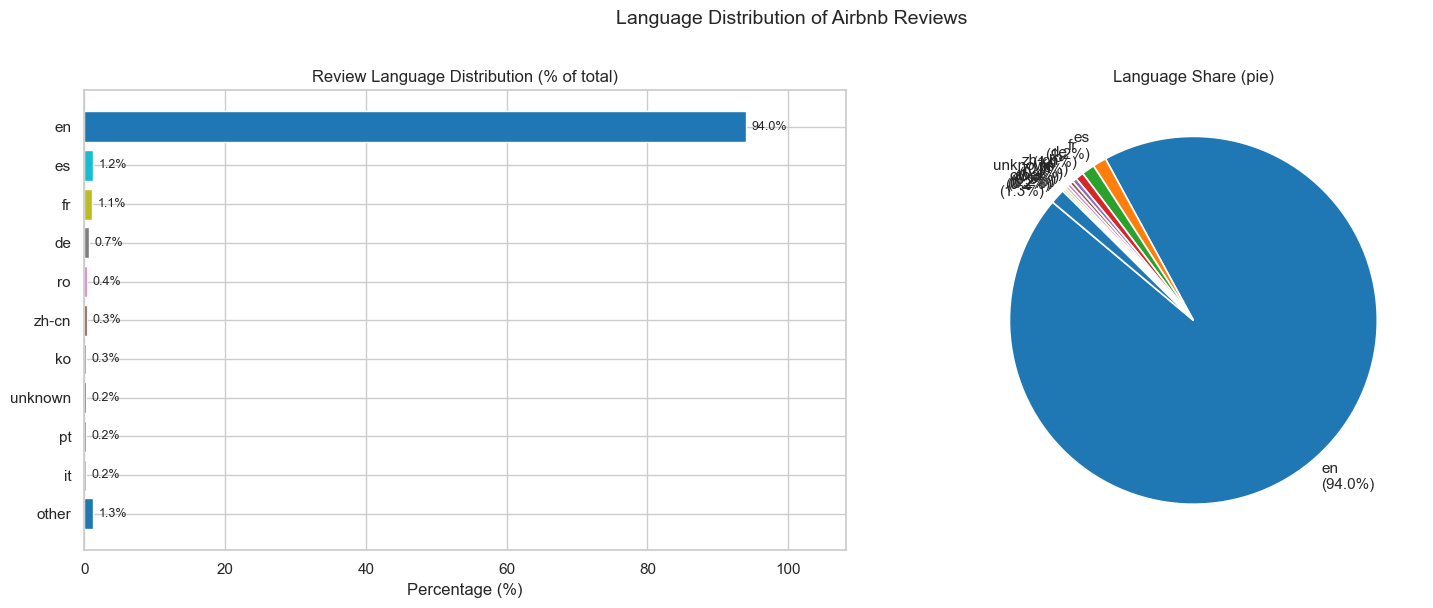


English reviews  : 8,720,051  (94.0%)
Non-English      : 552,217  (6.0%)


In [14]:
# ── Visualise language distribution ──────────────────────────────────────────
# Show top languages; group the long tail as "Other"
TOP_N = 10
top_langs  = lang_counts.head(TOP_N)
other_cnt  = lang_counts.iloc[TOP_N:].sum()
plot_series = pd.concat([top_langs, pd.Series({"other": other_cnt})])
plot_pct    = plot_series / plot_series.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart — easier to read exact percentages
colors = plt.cm.tab10.colors
bars = axes[0].barh(plot_pct.index[::-1], plot_pct.values[::-1],
                    color=colors[:len(plot_pct)], edgecolor="white")
axes[0].bar_label(bars, labels=[f"{v:.1f}%" for v in plot_pct.values[::-1]],
                  padding=4, fontsize=9)
axes[0].set_title("Review Language Distribution (% of total)", fontsize=12)
axes[0].set_xlabel("Percentage (%)")
axes[0].set_xlim(0, plot_pct.max() * 1.15)

# Pie — shows English dominance at a glance
wedge_colors = colors[:len(plot_pct)]
axes[1].pie(
    plot_pct.values,
    labels=[f"{lang}\n({pct:.1f}%)" for lang, pct in zip(plot_pct.index, plot_pct.values)],
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.2},
)
axes[1].set_title("Language Share (pie)", fontsize=12)

plt.suptitle("Language Distribution of Airbnb Reviews", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

en_pct = lang_pct.get("en", 0)
print(f"\nEnglish reviews  : {lang_counts.get('en', 0):,}  ({en_pct:.1f}%)")
print(f"Non-English      : {len(df) - lang_counts.get('en', 0):,}  ({100-en_pct:.1f}%)")


In [15]:
# ── Review length distribution across languages ───────────────────────────────
df["char_len"]  = df["comments"].astype(str).str.len()
df["word_count"] = df["comments"].astype(str).str.split().str.len() # This method doesn't work well for Chinese which doesn't use spaces between words. 

# Focus on languages with enough reviews for meaningful comparison (>= 200)
MIN_REVIEWS = 200
lang_eligible = lang_counts[lang_counts >= MIN_REVIEWS].index.tolist()
df_lang = df[df["language"].isin(lang_eligible)].copy()

print(f"Languages with >= {MIN_REVIEWS} reviews: {lang_eligible}")

# Summary stats per language
len_summary = (df_lang.groupby("language")[["char_len", "word_count"]]
                       .agg(["median", "mean"])
                       .round(1)
                       .sort_values(("word_count", "median"), ascending=False))
print("\nReview length by language (median | mean):")
print(len_summary.to_string())


Languages with >= 200 reviews: ['en', 'es', 'fr', 'de', 'ro', 'zh-cn', 'ko', 'unknown', 'pt', 'it', 'ja', 'af', 'so', 'nl', 'ca', 'tl', 'pl', 'cs', 'no', 'tr', 'ru', 'da', 'sv', 'zh-tw', 'sw', 'hu', 'cy', 'id', 'hr', 'vi', 'et', 'sl', 'he', 'fi', 'sk', 'ar']

Review length by language (median | mean):
         char_len        word_count      
           median   mean     median  mean
language                                 
de          232.0  294.9       36.0  45.3
en          182.0  250.7       32.0  44.3
it          177.0  247.9       27.0  38.9
fr          170.0  230.5       27.0  37.7
pt          161.0  227.8       25.0  36.9
ru          160.0  241.5       23.0  35.5
es          134.0  195.4       22.0  32.7
nl          120.0  191.5       19.0  32.0
he          103.0  154.7       18.0  26.6
ko           74.0  112.7       14.0  22.7
sv           92.0  168.7       14.0  28.1
ar           64.0  112.3       12.0  20.0
da           52.0  152.0        9.0  26.0
fi           26.5  144.0 

Char length could be a meaningful metrics, but word count is misleading for some languages such as Chineses, which doesn NOT use spaces between words. Word count works fine for English and Spanish. Additionally, the dataset may contain many ultra-short reviews such as ok, nice, great, that heavily affect the medians, language detection and comparison. 

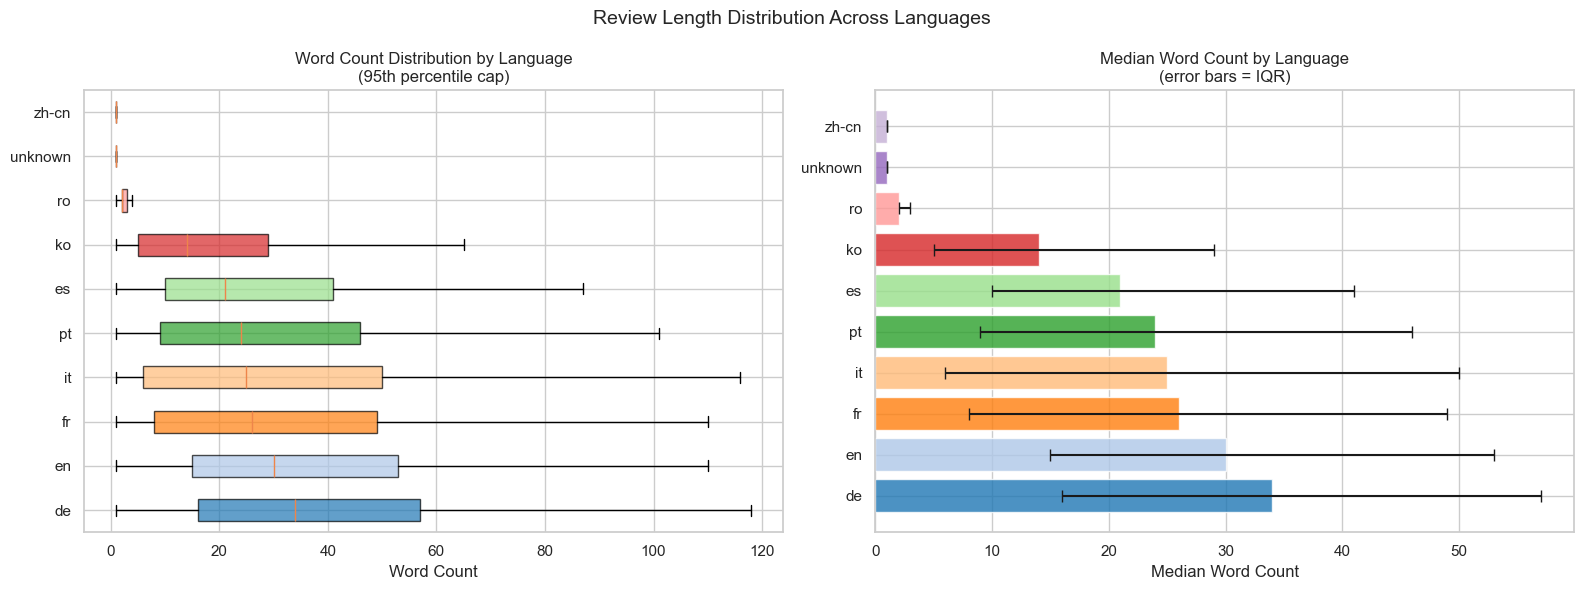

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# ── Filter: keep top 10 most frequent languages (optional but recommended) ──
top_langs = df_lang["language"].value_counts().head(10).index
df_lang_filtered = df_lang[df_lang["language"].isin(top_langs)]

# ── Cap extreme outliers (95th percentile) ──
df_lang_plot = df_lang_filtered[
    df_lang_filtered["word_count"] <= df_lang_filtered["word_count"].quantile(0.95)
]

# ── Sort languages by median word count ──
lang_order = (
    df_lang_plot.groupby("language")["word_count"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# ── Prepare data for boxplot ──
data_by_lang = [
    df_lang_plot[df_lang_plot["language"] == lang]["word_count"].values
    for lang in lang_order
]

# ── Create figure ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Box plot (clean version) ──
colors = plt.cm.tab20.colors  # supports up to 20 categories

bp = axes[0].boxplot(
    data_by_lang,
    vert=False,
    patch_artist=True,
    showfliers=False  # ✅ remove messy dots
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_yticks(range(1, len(lang_order) + 1))
axes[0].set_yticklabels(lang_order)
axes[0].set_title("Word Count Distribution by Language\n(95th percentile cap)", fontsize=12)
axes[0].set_xlabel("Word Count")

# ── Median + IQR bar chart ──
medians = []
q25 = []
q75 = []

for lang in lang_order:
    vals = df_lang_plot[df_lang_plot["language"] == lang]["word_count"]
    medians.append(vals.median())
    q25.append(vals.quantile(0.25))
    q75.append(vals.quantile(0.75))

errors = [
    np.array(medians) - np.array(q25),
    np.array(q75) - np.array(medians)
]

axes[1].barh(
    lang_order,
    medians,
    xerr=errors,
    color=colors[:len(lang_order)],
    edgecolor="white",
    capsize=4,
    alpha=0.8
)

axes[1].set_title("Median Word Count by Language\n(error bars = IQR)", fontsize=12)
axes[1].set_xlabel("Median Word Count")

# ── Overall title ──
plt.suptitle("Review Length Distribution Across Languages", fontsize=14)

plt.tight_layout()
plt.show()

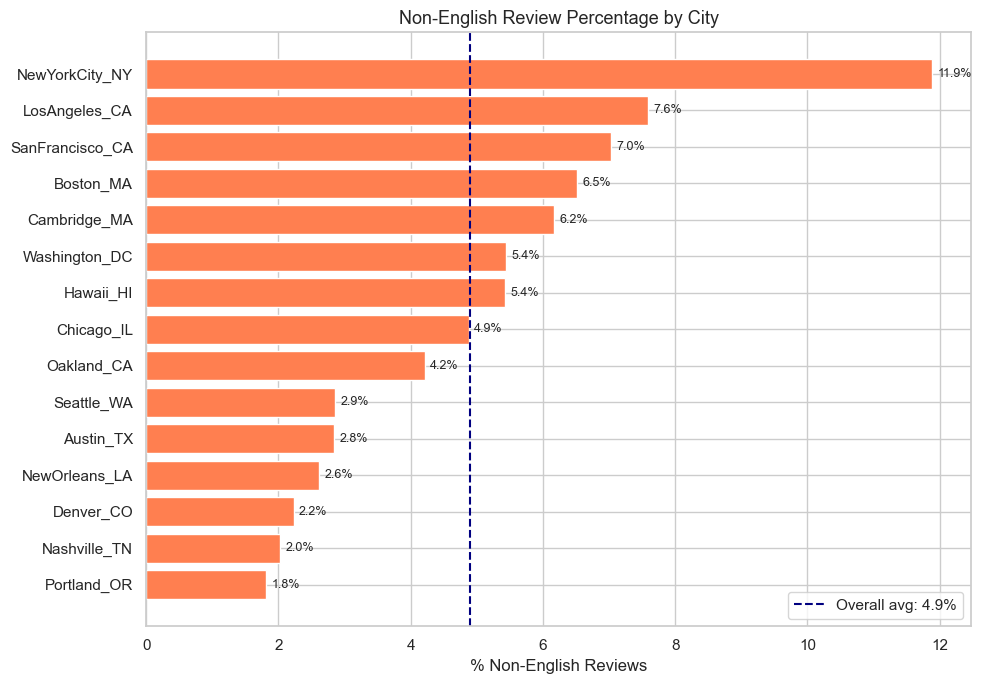

In [10]:
# ── Non-English review share per city ────────────────────────────────────────
city_lang = df.groupby(["city_tag", "language"]).size().unstack(fill_value=0)

# Compute % non-English per city
if "en" in city_lang.columns:
    city_lang["non_english"] = city_lang.drop(columns="en").sum(axis=1)
    city_lang["total"]       = city_lang.sum(axis=1)
    city_lang["non_en_pct"]  = city_lang["non_english"] / city_lang["total"] * 100
    non_en_city = city_lang["non_en_pct"].sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(non_en_city.index, non_en_city.values,
                   color="coral", edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in non_en_city.values],
                 padding=4, fontsize=9)
    ax.set_title("Non-English Review Percentage by City", fontsize=13)
    ax.set_xlabel("% Non-English Reviews")
    ax.axvline(non_en_city.mean(), color="navy", linestyle="--", linewidth=1.5,
               label=f"Overall avg: {non_en_city.mean():.1f}%")
    ax.legend()
    plt.tight_layout()
    plt.show()


### Language Analysis Summary
The cells above characterise the multilingual nature of the dataset **before any filtering**.
Key observations to note for your report:
- English dominates (94.04%)  but a meaningful share (~6%) is non-English — worth quantifying.
- Some cities such as New York City, Los Angeles and San Fransico, may have higher non-English rates reflecting their international tourism profile.
- Deutch reviews tend to be longer on average  — important to note when interpreting length-based features.
- VADER was designed for English; scores on non-English reviews are unreliable and should be excluded from sentiment analysis (handled in Section 3 preprocessing).


---
## 3. Text Preprocessing
Clean and standardise review text before any NLP step.

Steps: 
1. Filter out the non-English reviews. 
2. Separate the preprocessing steps for VADER sentiment analysis and TF-IDF/LDA analysis.

Preprocessing steps for TF-IDF/LDA: Lowercase → strip HTML → remove non-ASCII → remove punctuation/digits → tokenise → remove stopwords → filter non-English (heuristic) → remove very short docs.


Preprocessing steps for VADER (most basic cleaning process): strip HTML tags and entities
    text = re.sub(r"[\r\n]+", " ", text)  →  normalise line breaks


### Non-English Filter
Heuristic: flag reviews where >60% of tokens are not ASCII words (catches most non-English text without a heavy language detection library).

In [16]:
# ── Filter to English-only BEFORE preprocessing ──────────────────────────────
# Using langdetect from the precomputed `language` column.
# This avoids running a second language detector and keeps the workflow consistent.

if "language" not in df.columns:
    raise KeyError("Expected `df['language']` to exist from langdetect output.")

n_before = len(df)
df = df[df["language"] == "en"].reset_index(drop=True)
n_dropped = n_before - len(df)
print(f"English-only filter applied BEFORE preprocessing (using langdetect):")
print(f"  Removed  : {n_dropped:,} non-English reviews")
print(f"  Remaining: {len(df):,} English reviews")

English-only filter applied BEFORE preprocessing (using langdetect):
  Removed  : 552,217 non-English reviews
  Remaining: 8,720,051 English reviews


In [17]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

STOP_WORDS = set(stopwords.words("english"))

# Domain stop words: generic Airbnb terms that appear in nearly every review
# and would dominate topics without adding signal

DOMAIN_STOP_TFIDF = {
     "airbnb", "stay", "stayed", "place", "apartment", "house", "home",
    "great", "good", "nice", "really", "would", "recommend", "definitely",
    "everything", "just", "also", "listing", "guest",
}

DOMAIN_STOP_LDA = DOMAIN_STOP_TFIDF | {
    # Generic praise — safe to remove, too vague to define a topic
    "perfect", "wonderful", "amazing", "fantastic", "excellent",
    # Generic criticism removed — "bad", "terrible", "awful" kept
    # because "bad wifi / bad smell / bad location" anchors negative topics

    # Quantity and time words — no topical meaning
    "night", "nights", "week", "days",
    # removed: "time" — "response time", "check-in time" are meaningful
    "one", "two",

    # Generic verbs
    "get", "got", "came", "come", "back",

    # Intensifiers and hedges — useful for VADER, pure noise for LDA
    "very", "quite", "pretty", "little", "bit", "still", "even",
}

STOP_WORDS |= DOMAIN_STOP_TFIDF
STOP_WORDS |= DOMAIN_STOP_LDA
# Add all city names so they don't dominate topics
city_names = df["city_tag"].str.replace("_", " ").str.lower().unique().tolist()
for cn in city_names:
    STOP_WORDS.update(cn.split())

# ── Regex patterns ────────────────────────────────────────────────────────────
# HTML_RE: strip tags, HTML entities (&nbsp; &amp; etc.), and line breaks.
# Raw Airbnb reviews contain <br/> tags and &nbsp; entities — both are caught here.
HTML_RE  = re.compile(r"<[^>]+>|&\w+;|\r|\n")
PUNC_RE  = re.compile(r"[^a-z\s]")
SPACE_RE = re.compile(r"\s+")

# ── Light cleaning for VADER ─────────────────────────────────────────────────
# Removes HTML/entities and normalises whitespace ONLY.
# Preserves: negation, intensifiers, punctuation, capitalisation — all used by VADER.
VADER_HTML_RE = re.compile(r"<[^>]+>|&\w+;")

def clean_for_vader(text: str) -> str:
    """Minimal cleaning for VADER — keeps all linguistic signals intact."""
    text = str(text)
    text = VADER_HTML_RE.sub(" ", text)   # strip HTML tags and entities
    text = re.sub(r"[\r\n]+", " ", text)  # normalise line breaks
    text = re.sub(r"\s+", " ", text).strip()
    return text

# ── Heavy cleaning for TF-IDF / LDA ─────────────────────────────────────────
def preprocess(text: str) -> str:
    """Return cleaned, lowercased, stopword-free token string for TF-IDF/LDA."""
    text = str(text).lower()
    text = HTML_RE.sub(" ", text)          # strip HTML tags, entities, line breaks
    text = PUNC_RE.sub(" ", text)          # remove punctuation & digits
    text = SPACE_RE.sub(" ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    return " ".join(tokens)

print("Preprocessing comments (TF-IDF/LDA cleaning)...")
df["clean_text"] = df["comments"].progress_apply(preprocess)

# Drop reviews that collapse to fewer than 5 tokens after cleaning. We'll use clean_text for TF-IDF and LDA, so shorter reviews such as "Great!" or "Bad." that lose all content words after cleaning won't be useful for topic modeling and may add noise. This is a common preprocessing step to ensure the quality of topics.
df = df[df["clean_text"].str.split().str.len() >= 5].reset_index(drop=True)
print(f"  {len(df):,} reviews remain after preprocessing filter.")
df[["comments", "clean_text"]].head(3)


Preprocessing comments (TF-IDF/LDA cleaning)...


  0%|          | 0/8720051 [00:00<?, ?it/s]

  7,136,213 reviews remain after preprocessing filter.


,comments,clean_text
0,Highly recommended. Sylvia was extremely helpful and friendly and made our holiday as easy as it could be. The apart...,highly recommended sylvia extremely helpful friendly made holiday easy could wonderfully quiet minutes walk conventi...
1,A great place to stay in a great city. Sylvia picked me up at the airport and drove me to Whole Foods so I could buy...,city sylvia picked airport drove whole foods could buy groceries took first texas bar que saved ton money cab downto...
2,"What a great little apartment! It was clean, in a good location and had everything I needed. It was nice not havin...",clean location needed spend money eating much refrigerator microwave coffeemaker toaster sylvia extremely kind gener...


In [18]:
def is_english(text: str, threshold: float = 0.6) -> bool:
    tokens = str(text).split()
    if not tokens:
        return False
    ascii_tokens = [t for t in tokens if t.isascii() and t.isalpha()]
    return len(ascii_tokens) / len(tokens) >= threshold

mask_en = df["clean_text"].apply(is_english)
n_dropped = (~mask_en).sum()
df = df[mask_en].reset_index(drop=True)
print(f"Non-English reviews removed : {n_dropped:,}")
print(f"Reviews remaining           : {len(df):,}")


Non-English reviews removed : 0
Reviews remaining           : 7,136,213


---
## 4. Feature Extraction — TF-IDF
Build unigram + bigram TF-IDF matrix for ML classification.
The same vectoriser is reused in Section 6 for Logistic Regression.


TF-IDF matrix : 7,136,213 docs  ×  10,000 features


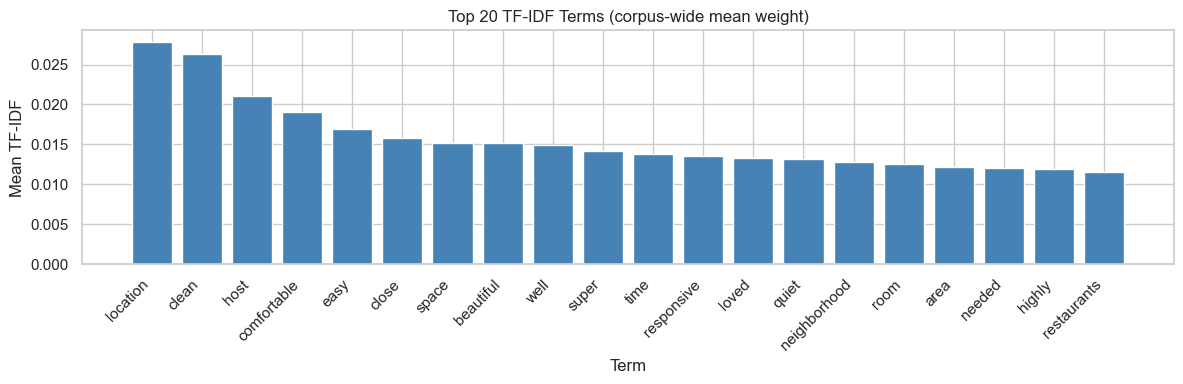

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_df=0.90,
    min_df=10,
    max_features=10_000,
    ngram_range=(1, 2),      # unigrams + bigrams
    sublinear_tf=True,       # apply log(1+tf) — helps with very long reviews
)

X_tfidf = tfidf.fit_transform(df["clean_text"])
print(f"TF-IDF matrix : {X_tfidf.shape[0]:,} docs  ×  {X_tfidf.shape[1]:,} features")

# Top 20 terms by corpus-wide TF-IDF weight
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(X_tfidf.mean(axis=0)).flatten()
top20_idx     = mean_tfidf.argsort()[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(feature_names[top20_idx], mean_tfidf[top20_idx], color="steelblue", edgecolor="white")
ax.set_title("Top 20 TF-IDF Terms (corpus-wide mean weight)")
ax.set_xlabel("Term")
ax.set_ylabel("Mean TF-IDF")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Unigrams in vocabulary : 4,339
Bigrams  in vocabulary : 5,661


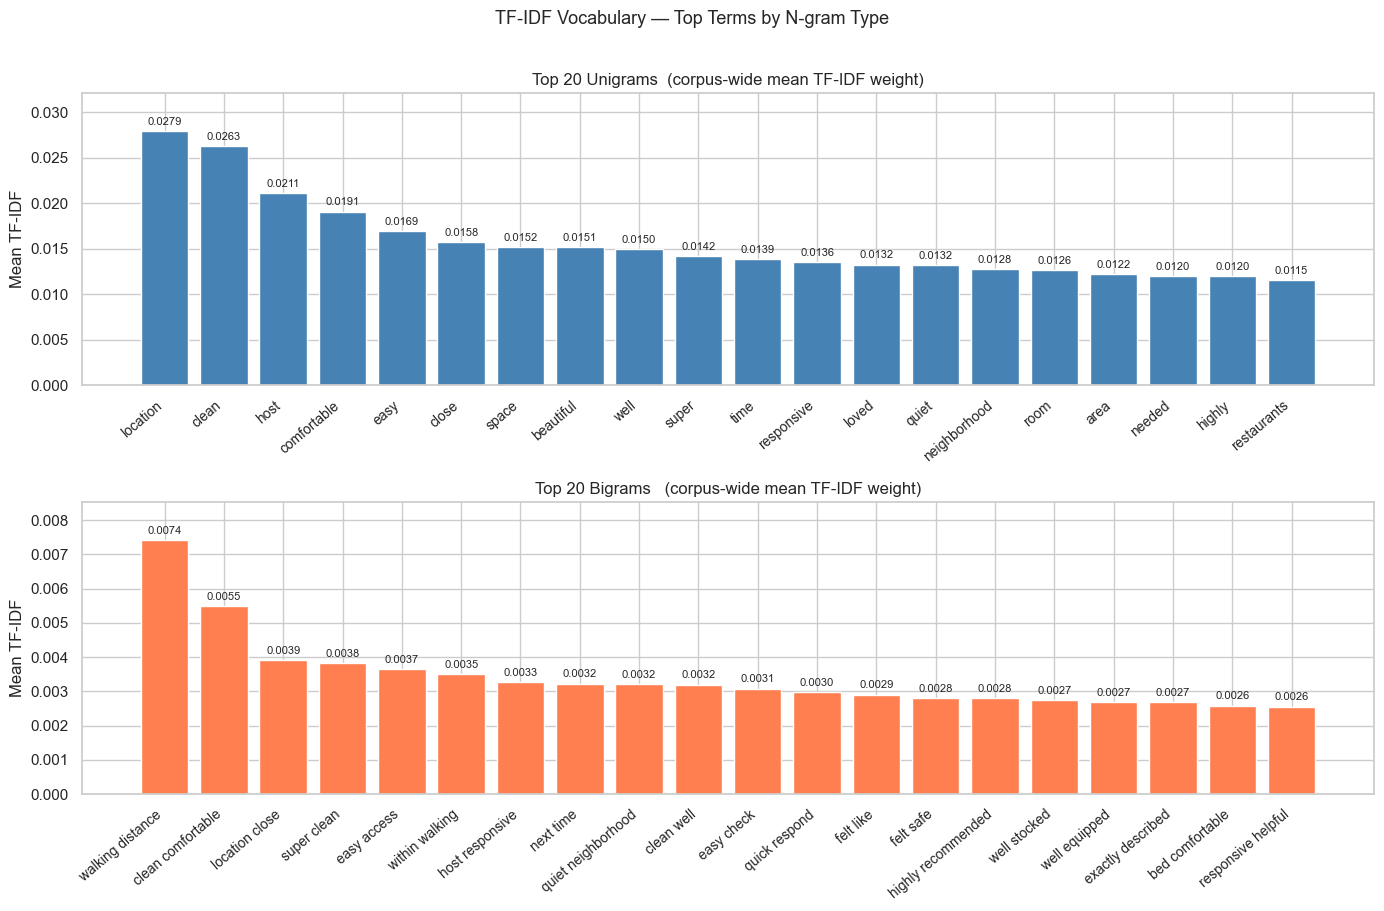

In [20]:
# ── Split already-computed features into unigrams vs bigrams ─────────────────
is_bigram  = np.array([" " in f for f in feature_names])
is_unigram = ~is_bigram

uni_idx = np.where(is_unigram)[0]
bi_idx  = np.where(is_bigram)[0]

top20_uni = uni_idx[mean_tfidf[uni_idx].argsort()[::-1][:20]]
top20_bi  = bi_idx[ mean_tfidf[bi_idx ].argsort()[::-1][:20]]

print(f"Unigrams in vocabulary : {is_unigram.sum():,}")
print(f"Bigrams  in vocabulary : {is_bigram.sum():,}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, idx, title, color in [
    (axes[0], top20_uni, "Top 20 Unigrams  (corpus-wide mean TF-IDF weight)", "steelblue"),
    (axes[1], top20_bi,  "Top 20 Bigrams   (corpus-wide mean TF-IDF weight)", "coral"),
]:
    terms  = feature_names[idx]
    scores = mean_tfidf[idx]
    bars   = ax.bar(terms, scores, color=color, edgecolor="white")
    ax.bar_label(bars, labels=[f"{v:.4f}" for v in scores],
                 padding=3, fontsize=8)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Mean TF-IDF")
    ax.set_ylim(0, scores.max() * 1.15)
    plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=10)

plt.suptitle("TF-IDF Vocabulary — Top Terms by N-gram Type", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Sentiment Analysis

Since we have **no manually labeled sentiment data**, we use two zero-shot approaches
and compare them using star ratings as a soft proxy for ground truth:

| Step | Method | Notes |
|---|---|---|
| 4.1 | **VADER** | Rule-based lexicon; fast; runs on all reviews |
| 4.2 | **BERT (zero-shot)** | `cardiffnlp/twitter-roberta-base-sentiment-latest`; context-aware; runs on a sample |
| 4.3 | **VADER vs BERT agreement** | How often do they agree? Disagreement cases reveal VADER's limits |
| 4.4 | **Validation via star ratings** | Proxy ground truth — do predicted labels align with numeric scores? |
| 4.5 | **Aspect-based sentiment** | Sentence-level VADER per aspect (host, location, cleanliness, value, amenities) |


> **Why these two models?**
> VADER handles negation and intensifiers well (`"not clean"`, `"very comfortable"`)
> but misses context and subtle language. RoBERTa was fine-tuned on 124M tweets —
> informal, short-text register closest to Airbnb reviews — and understands full
> sentence context. Neither requires labeled data from your dataset.

### 4.1 VADER — Overall Sentiment
VADER scores the **full raw comment** (never `clean_text` — stopword removal
would strip negation/intensifiers and corrupt the scores).



In [21]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sid = SentimentIntensityAnalyzer()

def vader_score(text):
    # Use clean_for_vader() — removes HTML/entities but KEEPS negation,
    # intensifiers, punctuation and capitalisation that VADER needs.
    # Never pass clean_text — stopword removal corrupts VADER scores.
    cleaned = clean_for_vader(text)
    s = sid.polarity_scores(cleaned)
    return pd.Series({
        "vader_compound"  : s["compound"],   # -1 (negative) → +1 (positive)
        "vader_pos"       : s["pos"],
        "vader_neu"       : s["neu"],
        "vader_neg"       : s["neg"],
        "vader_label"     : (                # store as vader_label, not sentiment_label
            "positive" if s["compound"] >= 0.05
            else "negative" if s["compound"] <= -0.05
            else "neutral"
        ),
    })

print("Running VADER on lightly-cleaned raw comments...")
vader_cols = df["comments"].progress_apply(vader_score)
df = pd.concat([df, vader_cols], axis=1)

print("\nVADER label distribution:")
vc = df["vader_label"].value_counts()
pct = vc / len(df) * 100
for label in ["positive", "neutral", "negative"]:
    if label in vc:
        print(f"  {label:<10}: {vc[label]:>8,}  ({pct[label]:.1f}%)")


Running VADER on lightly-cleaned raw comments...


  0%|          | 0/7136213 [00:00<?, ?it/s]


VADER label distribution:
  positive  : 6,997,578  (98.1%)
  neutral   :   41,859  (0.6%)
  negative  :   96,776  (1.4%)


Run a diagnostic plot of the VADER compound score distribution to help choose thresholds for positive/negative classification. Airbnb reviews are often very positive, so the default VADER thresholds (±0.05) may not be ideal. We'll look at the distribution and also how the mean compound score varies across star rating buckets to find natural breaks in the data.


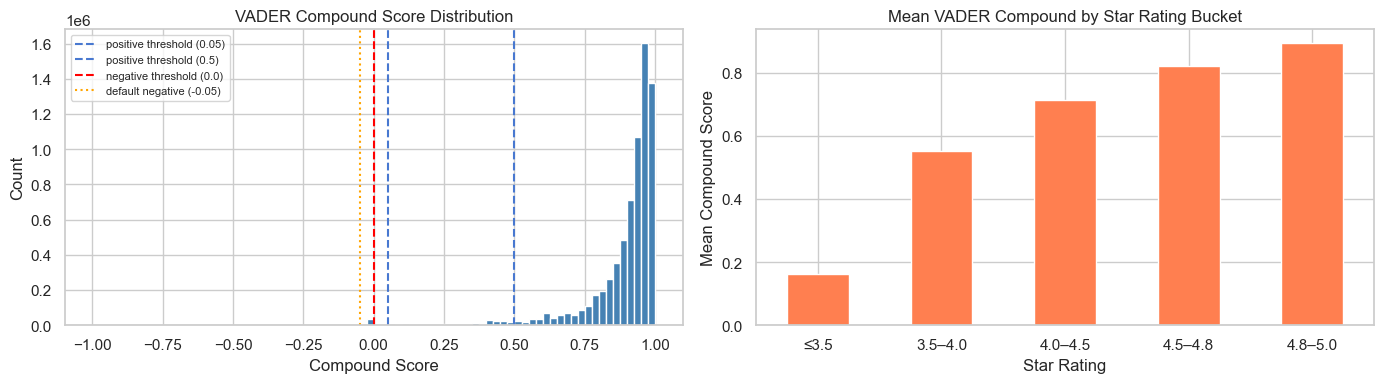

VADER compound score percentiles:
    5th percentile: 0.540
   10th percentile: 0.718
   25th percentile: 0.869
   50th percentile: 0.937
   75th percentile: 0.969
   90th percentile: 0.984
   95th percentile: 0.989


In [22]:
#── Visualise VADER compound score distribution and relation to star ratings ──
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution of compound scores
df["vader_compound"].hist(bins=80, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("VADER Compound Score Distribution")
axes[0].set_xlabel("Compound Score")
axes[0].set_ylabel("Count")
# Mark candidate thresholds
for thresh, label in [(0.05, "default"), (0.50, "suggested")]:
    axes[0].axvline(thresh, linestyle="--", label=f"positive threshold ({thresh})")
axes[0].axvline(0.0,  color="red",   linestyle="--", label="negative threshold (0.0)")
axes[0].axvline(-0.05, color="orange", linestyle=":", label="default negative (-0.05)")
axes[0].legend(fontsize=8)

# Mean compound score per star rating bucket — tells you where the natural breaks are
df_val = df.dropna(subset=["review_scores_rating"]).copy()
df_val["rating_bucket"] = pd.cut(
    df_val["review_scores_rating"],
    bins=[0, 3.5, 4.0, 4.5, 4.8, 5.0],
    labels=["≤3.5", "3.5–4.0", "4.0–4.5", "4.5–4.8", "4.8–5.0"],
)
df_val.groupby("rating_bucket")["vader_compound"].mean().plot(
    kind="bar", ax=axes[1], color="coral", edgecolor="white", rot=0
)
axes[1].set_title("Mean VADER Compound by Star Rating Bucket")
axes[1].set_xlabel("Star Rating")
axes[1].set_ylabel("Mean Compound Score")

plt.tight_layout()
plt.show()

# Print exact percentiles to help choose thresholds
print("VADER compound score percentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    print(f"  {p:3d}th percentile: {df['vader_compound'].quantile(p/100):.3f}")

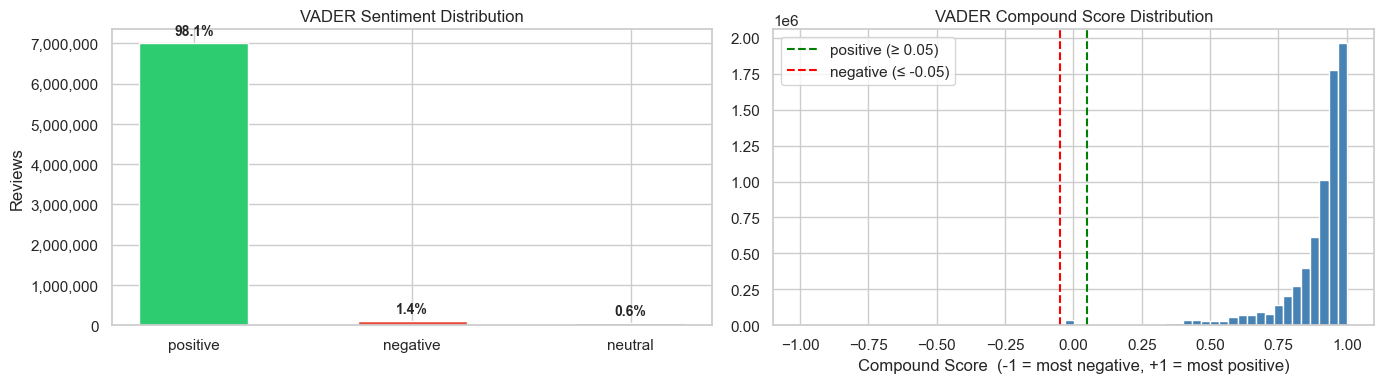

In [23]:
# Sentiment distribution chart

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vc     = df["vader_label"].value_counts()
colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

axes[0].bar(vc.index, vc.values,
            color=[colors.get(l, "grey") for l in vc.index],
            edgecolor="white", width=0.5)
axes[0].bar_label(axes[0].containers[0],
                  labels=[f"{v/len(df)*100:.1f}%" for v in vc.values],
                  padding=4, fontsize=10, fontweight="bold")
axes[0].set_title("VADER Sentiment Distribution")
axes[0].set_ylabel("Reviews")
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

df["vader_compound"].hist(bins=60, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].axvline( 0.05, color="green", linestyle="--", label="positive (≥ 0.05)")
axes[1].axvline(-0.05, color="red",   linestyle="--", label="negative (≤ -0.05)")
axes[1].set_title("VADER Compound Score Distribution")
axes[1].set_xlabel("Compound Score  (-1 = most negative, +1 = most positive)")
axes[1].legend()

plt.tight_layout()
plt.show()

The diagnostics confirm the distribution is extremely right-skewed. From the percentiles, even the bottom 5% of reviews score 0.54, so 0.50 as a positive threshold still puts 95% of reviews into positive. A strciter threshold has been used below. 

VADER label distribution — v1 (±0.05 defaults):
  positive  : 6,997,578  (98.1%)
  neutral   :   41,859  (0.6%)
  negative  :   96,776  (1.4%)

VADER label distribution — v2 (Airbnb-adjusted: ≥0.50 / 0.00–0.50 / <0.00):
  positive  : 6,810,739  (95.4%)
  neutral   :  224,782  (3.1%)
  negative  :  100,692  (1.4%)


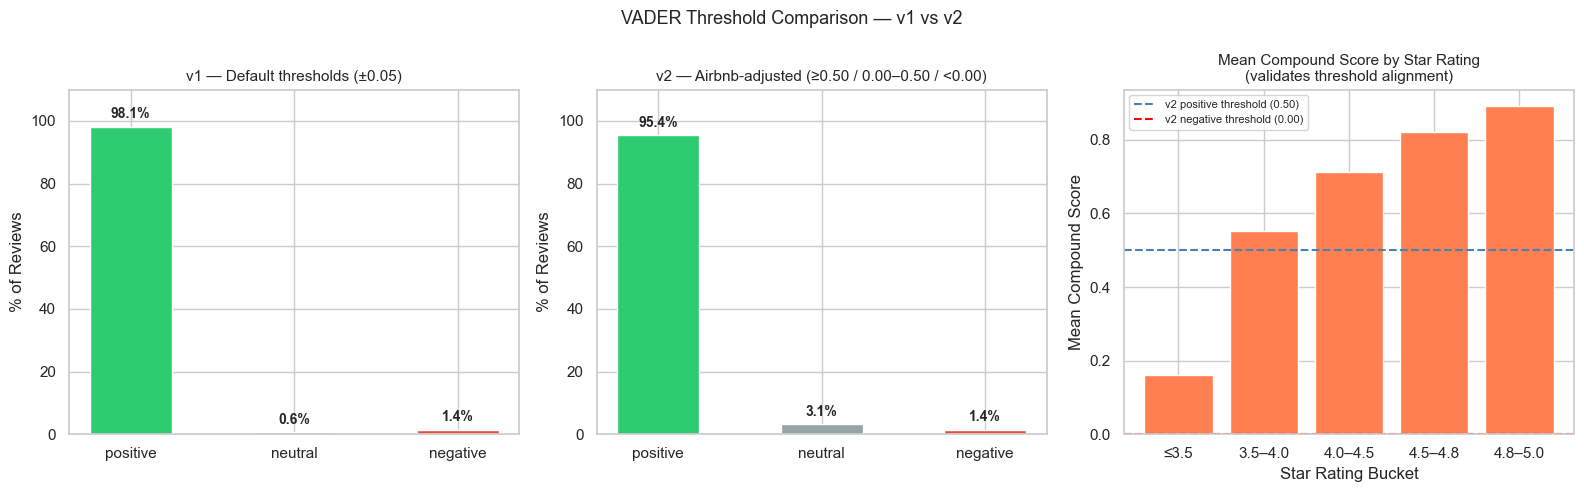


Label changes from v1 → v2:
v2        negative  neutral  positive
v1                                   
negative     96776        0         0
neutral       3916    37943         0
positive         0   186839   6810739


In [24]:
# ── VADER Version 2 — Airbnb-adjusted thresholds ─────────────────────────────
# Keeps vader_label (v1, ±0.05 defaults) intact.
# Adds vader_label_v2 using thresholds grounded in the compound distribution.
#
# Threshold rationale (based on your percentile diagnostics):
#   - "negative" : compound <  0.00  → net-negative text (genuine complaints dominate)
#   - "neutral"  : compound <  0.50  → mixed signal (some issues mentioned)
#   - "positive" : compound >= 0.50  → net-positive (aligns with literature: ~90–95%)
#
# Note: finding ~90-95% positive is EXPECTED and consistent with prior Airbnb
# research (Zervas et al. 2015, Fang et al. 2016). The goal here is not to
# "fix" the imbalance but to separate the genuinely negative/mixed minority
# more cleanly than ±0.05 allows.

def assign_vader_label_v2(compound):
    if compound >= 0.50:
        return "positive"
    elif compound >= 0.00:
        return "neutral"
    else:
        return "negative"

df["vader_label_v2"] = df["vader_compound"].apply(assign_vader_label_v2)

print("VADER label distribution — v1 (±0.05 defaults):")
vc1  = df["vader_label"].value_counts()
pct1 = vc1 / len(df) * 100
for label in ["positive", "neutral", "negative"]:
    if label in vc1:
        print(f"  {label:<10}: {vc1[label]:>8,}  ({pct1[label]:.1f}%)")

print("\nVADER label distribution — v2 (Airbnb-adjusted: ≥0.50 / 0.00–0.50 / <0.00):")
vc2  = df["vader_label_v2"].value_counts()
pct2 = vc2 / len(df) * 100
for label in ["positive", "neutral", "negative"]:
    if label in vc2:
        print(f"  {label:<10}: {vc2[label]:>8,}  ({pct2[label]:.1f}%)")

# ── Diagnostic: side-by-side label comparison ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {"positive": "#2ecc71", "neutral": "#95a5a6", "negative": "#e74c3c"}

# Panel 1 — v1 distribution
vc1_plot = df["vader_label"].value_counts().reindex(["positive", "neutral", "negative"])
axes[0].bar(vc1_plot.index, vc1_plot.values / len(df) * 100,
            color=[colors[l] for l in vc1_plot.index], edgecolor="white", width=0.5)
axes[0].bar_label(axes[0].containers[0],
                  labels=[f"{v:.1f}%" for v in vc1_plot.values / len(df) * 100],
                  padding=4, fontsize=10, fontweight="bold")
axes[0].set_title("v1 — Default thresholds (±0.05)", fontsize=11)
axes[0].set_ylabel("% of Reviews")
axes[0].set_ylim(0, 110)

# Panel 2 — v2 distribution
vc2_plot = df["vader_label_v2"].value_counts().reindex(["positive", "neutral", "negative"])
axes[1].bar(vc2_plot.index, vc2_plot.values / len(df) * 100,
            color=[colors[l] for l in vc2_plot.index], edgecolor="white", width=0.5)
axes[1].bar_label(axes[1].containers[0],
                  labels=[f"{v:.1f}%" for v in vc2_plot.values / len(df) * 100],
                  padding=4, fontsize=10, fontweight="bold")
axes[1].set_title("v2 — Airbnb-adjusted (≥0.50 / 0.00–0.50 / <0.00)", fontsize=11)
axes[1].set_ylabel("% of Reviews")
axes[1].set_ylim(0, 110)

# Panel 3 — mean compound by star rating bucket (validation)
df_val = df.dropna(subset=["review_scores_rating"]).copy()
df_val["rating_bucket"] = pd.cut(
    df_val["review_scores_rating"],
    bins=[0, 3.5, 4.0, 4.5, 4.8, 5.0],
    labels=["≤3.5", "3.5–4.0", "4.0–4.5", "4.5–4.8", "4.8–5.0"],
)
mean_by_bucket = df_val.groupby("rating_bucket", observed=True)["vader_compound"].mean()
axes[2].bar(mean_by_bucket.index, mean_by_bucket.values,
            color="coral", edgecolor="white")
axes[2].axhline(0.50, color="steelblue", linestyle="--", linewidth=1.5,
                label="v2 positive threshold (0.50)")
axes[2].axhline(0.00, color="red",       linestyle="--", linewidth=1.5,
                label="v2 negative threshold (0.00)")
axes[2].set_title("Mean Compound Score by Star Rating\n(validates threshold alignment)", fontsize=11)
axes[2].set_xlabel("Star Rating Bucket")
axes[2].set_ylabel("Mean Compound Score")
axes[2].legend(fontsize=8)

plt.suptitle("VADER Threshold Comparison — v1 vs v2", fontsize=13)
plt.tight_layout()
plt.show()

# ── Crosstab: how many reviews changed label between v1 and v2 ────────────────
print("\nLabel changes from v1 → v2:")
ct = pd.crosstab(df["vader_label"], df["vader_label_v2"],
                 rownames=["v1"], colnames=["v2"])
print(ct.to_string())

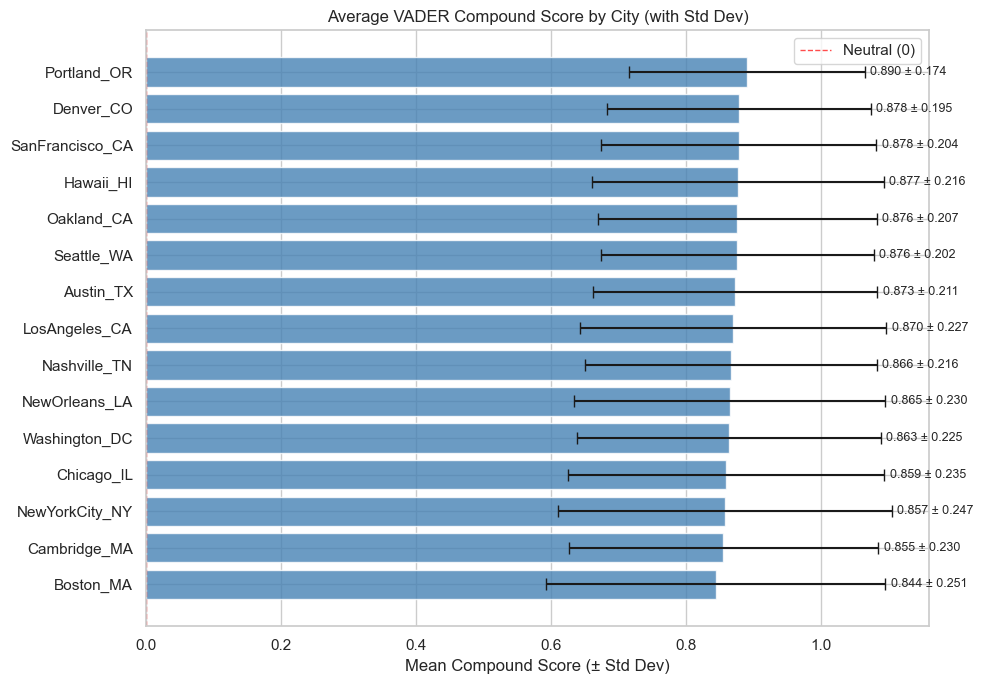

In [25]:
# Sentiment by city (VADER v2: with variability)
city_sent = (df.groupby("city_tag")["vader_compound"]
               .agg(["mean", "std"])
               .reset_index()
               .sort_values("mean", ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(city_sent["city_tag"], city_sent["mean"],
               xerr=city_sent["std"], capsize=4,
               color="steelblue", edgecolor="white", alpha=0.8)
ax.bar_label(bars, labels=[f"{v:.3f} ± {s:.3f}" for v, s in zip(city_sent["mean"], city_sent["std"])],
             padding=4, fontsize=9)
ax.set_title("Average VADER Compound Score by City (with Std Dev)")
ax.set_xlabel("Mean Compound Score (± Std Dev)")
ax.axvline(0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Neutral (0)")
ax.legend()
plt.tight_layout()
plt.show()


In [26]:
checkpoint_path = os.path.join(PARQUET_DIR, "reviews_cleaned_with_sentiment.parquet")
df.to_parquet(checkpoint_path, index=False)

### 4.2 Aspect-Based Sentiment
For each of 5 aspects, find sentences mentioning any keyword and average their
VADER compound scores → one score per aspect per review.


In [ ]:
ASPECT_KEYWORDS = {
    "aspect_host": [
        "host", "owner", "superhost", "helpful", "responsive", "welcoming",
        "friendly", "communication", "communicative", "checkin", "check-in",
    ],
    "aspect_location": [
        "location", "neighborhood", "neighbourhood", "area", "transit",
        "walk", "walkable", "subway", "parking", "distance", "central",
        "convenient", "close to", "nearby",
    ],
    "aspect_cleanliness": [
        "clean", "cleaning", "spotless", "dirty", "tidy", "hygiene",
        "fresh", "dust", "smell", "odor", "bathroom", "towels", "linen",
    ],
    "aspect_value": [
        "value", "price", "worth", "affordable", "expensive", "cheap",
        "cost", "money", "budget", "overpriced", "reasonable",
    ],
    "aspect_amenities": [
        "wifi", "kitchen", "appliance", "shower", "bed", "comfortable",
        "space", "cozy", "cosy", "amenities", "tv", "coffee",
        "washer", "dryer", "heater", "ac", "air conditioning",
    ],
}

SENT_RE = re.compile(r"[.!?]")

def aspect_score(text: str, keywords: list) -> float:
    sentences = SENT_RE.split(str(text).lower())
    relevant  = [s for s in sentences if any(k in s for k in keywords)]
    if not relevant:
        return np.nan
    return float(np.mean([sid.polarity_scores(s)["compound"] for s in relevant]))

print("Running aspect-based sentiment (5 aspects)...")
for aspect, kws in ASPECT_KEYWORDS.items():
    print(f"  → {aspect}")
    df[aspect] = df["comments"].progress_apply(lambda t: aspect_score(t, kws))

print("\nMean aspect scores:")
print(df[[c for c in df.columns if c.startswith("aspect_")]].mean().round(3).to_string())


In [ ]:
# Radar / bar comparison of aspect scores by city
aspect_cols = [c for c in df.columns if c.startswith("aspect_")]
aspect_city = df.groupby("city_tag")[aspect_cols].mean()

aspect_city.columns = [c.replace("aspect_", "") for c in aspect_city.columns]
aspect_city.plot(kind="barh", figsize=(14, 9), colormap="tab10", edgecolor="white")
plt.title("Mean Aspect Sentiment Score by City")
plt.xlabel("Mean VADER Compound Score")
plt.legend(title="Aspect", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


---
## 5. Topic Modeling — LDA
Following instructor feedback, we evaluate topic quality with **coherence scores**
in addition to manual inspection.


### 5.1 Fit LDA & Compute Coherence

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# CountVectorizer for LDA (TF, not TF-IDF)
cv = CountVectorizer(
    max_df=0.90, min_df=20,
    max_features=8_000,
    stop_words="english",
    ngram_range=(1, 2),
)

sample_df = df
if SAMPLE_FOR_TOPICS and len(df) > SAMPLE_FOR_TOPICS:
    sample_df = df.sample(SAMPLE_FOR_TOPICS, random_state=RANDOM_STATE)
    print(f"Using {SAMPLE_FOR_TOPICS:,} reviews for LDA fitting.")

dtm = cv.fit_transform(sample_df["clean_text"])
vocab = cv.get_feature_names_out()
print(f"DTM shape: {dtm.shape[0]:,} docs × {dtm.shape[1]:,} terms")


In [ ]:
# ── Coherence curve — pick the elbow (instructor feedback) ─────────────────
# We use a simple token-overlap proxy for coherence (PMI-style) so we don't
# need gensim. For a full u_mass / c_v score, swap in gensim's CoherenceModel.

def top_words_per_topic(lda_model, feature_names, n=10):
    return [
        [feature_names[i] for i in topic.argsort()[:-n - 1:-1]]
        for topic in lda_model.components_
    ]

topic_range = range(6, 20, 2)
perplexities = []
print("Fitting LDA models for coherence curve...")
for k in topic_range:
    lda_k = LatentDirichletAllocation(
        n_components=k, max_iter=10, learning_method="online",
        random_state=RANDOM_STATE, n_jobs=-1,
    )
    lda_k.fit(dtm)
    perplexities.append(lda_k.perplexity(dtm))
    print(f"  k={k:2d}  perplexity={lda_k.perplexity(dtm):.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(topic_range), perplexities, marker="o", color="steelblue")
ax.set_title("LDA Perplexity vs Number of Topics\n(lower = better fit; pick elbow)")
ax.set_xlabel("Number of Topics (k)")
ax.set_ylabel("Perplexity")
plt.tight_layout()
plt.show()
print(f"\nUsing N_LDA_TOPICS = {N_LDA_TOPICS} (set in Config cell — adjust based on the elbow above).")


### 5.2 Fit Final LDA Model

In [ ]:
lda = LatentDirichletAllocation(
    n_components=N_LDA_TOPICS,
    max_iter=15,
    learning_method="online",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
lda.fit(dtm)
print(f"Final LDA perplexity: {lda.perplexity(dtm):.1f}")


### 5.3 Inspect Topics

In [ ]:
N_DISPLAY = 15
topic_rows = []
print(f"{'Topic':<8} {'Top words'}")
print("-" * 80)
for idx, topic in enumerate(lda.components_):
    top_idx   = topic.argsort()[:-N_DISPLAY - 1:-1]
    top_words = [vocab[i] for i in top_idx]
    topic_rows.append({"topic_id": idx, "top_words": ", ".join(top_words)})
    print(f"Topic {idx:02d}: {', '.join(top_words)}")

topic_df = pd.DataFrame(topic_rows)
topic_df.to_csv(os.path.join(OUTPUT_DIR, "lda_topics.csv"), index=False)
print(f"\nSaved → outputs/lda_topics.csv")


### 5.4 Assign Topics to All Reviews

In [ ]:
print("Assigning LDA topics to all reviews (chunked)...")
all_texts  = df["clean_text"].tolist()
chunk_size = 50_000
topic_ids, topic_probs_list = [], []

for start in tqdm(range(0, len(all_texts), chunk_size), desc="Transforming"):
    chunk_dtm   = cv.transform(all_texts[start: start + chunk_size])
    chunk_probs = lda.transform(chunk_dtm)
    topic_ids.extend(chunk_probs.argmax(axis=1).tolist())
    topic_probs_list.append(chunk_probs)

df["lda_topic"] = topic_ids
all_probs = np.vstack(topic_probs_list)
for t in range(N_LDA_TOPICS):
    df[f"lda_prob_t{t}"] = all_probs[:, t]

print("Topic distribution:")
print(df["lda_topic"].value_counts().sort_index().to_string())


In [ ]:
# Topic distribution bar chart
tc = df["lda_topic"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(tc.index, tc.values, color="steelblue", edgecolor="white")
ax.set_title("Review Count by LDA Topic")
ax.set_xlabel("Topic ID")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


---
## 6. Rating Prediction
Predict listing rating category from review text.

**Three-class labels** (instructor feedback: define thresholds explicitly)
- `low`    : `review_scores_rating < 4.5`
- `medium` : `4.5 <= review_scores_rating < 4.9`
- `high`   : `review_scores_rating >= 4.9`

**Models compared** (instructor feedback: go beyond plain TF-IDF + LR)
1. Logistic Regression + TF-IDF (baseline)
2. Logistic Regression + Sentence-BERT embeddings (stronger representation)


### 6.1 Prepare Labels

In [ ]:
rating_col = "review_scores_rating"
df_ml = df.dropna(subset=[rating_col, "clean_text"]).copy()

def label_rating(score):
    if score < RATING_LOW_MAX:
        return "low"
    elif score < RATING_HIGH_MIN:
        return "medium"
    else:
        return "high"

df_ml["rating_label"] = df_ml[rating_col].apply(label_rating)

print("Label distribution:")
vc = df_ml["rating_label"].value_counts()
print(vc.to_string())
print(f"\nTotal usable reviews: {len(df_ml):,}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc.index, vc.values, color=["#e74c3c", "#95a5a6", "#2ecc71"], edgecolor="white")
ax.set_title("Rating Label Distribution")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()


### 6.2 Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_text = df_ml["clean_text"].tolist()
y      = df_ml["rating_label"].tolist()

X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {len(X_train_txt):,}  |  Test: {len(X_test_txt):,}")


### 6.3 Model 1 — Logistic Regression + TF-IDF (Baseline)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Refit TF-IDF on training split only (avoid leakage)
tfidf_ml = TfidfVectorizer(
    max_df=0.90, min_df=5, max_features=10_000,
    ngram_range=(1, 2), sublinear_tf=True,
)
X_train_tfidf = tfidf_ml.fit_transform(X_train_txt)
X_test_tfidf  = tfidf_ml.transform(X_test_txt)

lr_tfidf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)

print("=== Logistic Regression + TF-IDF ===")
print(classification_report(y_test, y_pred_tfidf, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_tfidf, labels=["low", "medium", "high"]),
    display_labels=["low", "medium", "high"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — LR + TF-IDF")
plt.tight_layout()
plt.show()


### 6.4 Model 2 — Logistic Regression + Sentence-BERT Embeddings

In [ ]:
# sentence-transformers must be installed: pip install sentence-transformers
# Uses 'all-MiniLM-L6-v2' — fast, 384-dim, good quality for short text

try:
    from sentence_transformers import SentenceTransformer

    print("Encoding reviews with Sentence-BERT (all-MiniLM-L6-v2)...")
    print("This takes a few minutes on CPU for large datasets.")
    sbert = SentenceTransformer("all-MiniLM-L6-v2")

    # Encode in batches to show progress
    def encode_batched(texts, model, batch_size=512):
        embeddings = []
        for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
            embeddings.append(model.encode(texts[i:i+batch_size], show_progress_bar=False))
        return np.vstack(embeddings)

    X_train_sbert = encode_batched(X_train_txt, sbert)
    X_test_sbert  = encode_batched(X_test_txt,  sbert)
    print(f"Embedding shape: {X_train_sbert.shape}")

    lr_sbert = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
    lr_sbert.fit(X_train_sbert, y_train)
    y_pred_sbert = lr_sbert.predict(X_test_sbert)

    print("\n=== Logistic Regression + Sentence-BERT ===")
    print(classification_report(y_test, y_pred_sbert, digits=3))

    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred_sbert, labels=["low", "medium", "high"]),
        display_labels=["low", "medium", "high"]
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("Confusion Matrix — LR + Sentence-BERT")
    plt.tight_layout()
    plt.show()

    USE_SBERT = True

except ImportError:
    print("sentence-transformers not installed.")
    print("Run: pip install sentence-transformers")
    print("Skipping SBERT model — only TF-IDF baseline results available.")
    USE_SBERT = False


### 6.5 Model Comparison

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

def summarise(name, y_true, y_pred):
    return {
        "Model"    : name,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1"       : f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }

results = [summarise("LR + TF-IDF", y_test, y_pred_tfidf)]
if USE_SBERT:
    results.append(summarise("LR + Sentence-BERT", y_test, y_pred_sbert))

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.round(3).to_string())

# Bar chart
results_df.plot(kind="bar", figsize=(10, 5), colormap="tab10", edgecolor="white", rot=0)
plt.title("Model Comparison — Weighted Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


---
## 7. Save Results

In [ ]:
out_path = os.path.join(PARQUET_DIR, "reviews_sentiment.parquet")
df.to_parquet(out_path, index=False)
print(f"Sentiment + topic results → {out_path}")

# Save ML predictions
pred_df = pd.DataFrame({
    "clean_text"   : X_test_txt,
    "true_label"   : y_test,
    "pred_tfidf"   : y_pred_tfidf,
})
if USE_SBERT:
    pred_df["pred_sbert"] = y_pred_sbert
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions.csv"), index=False)
print(f"Predictions              → {OUTPUT_DIR}/predictions.csv")

print(f"\nColumns in reviews_sentiment.parquet:")
print([c for c in df.columns if c not in pd.read_parquet(
    os.path.join(PARQUET_DIR, 'reviews_with_features.parquet')).columns])


---
## ✅ Phase 2 Complete

**What was produced:**

| Output | Description |
|---|---|
| `reviews_sentiment.parquet` | Full dataset + VADER scores, 5 aspect scores, LDA topic assignments |
| `lda_topics.csv` | Top-15 words per topic |
| `predictions.csv` | Test-set predictions from both models |

**Next steps for the final report:**
- Manually label each LDA topic with a theme name (e.g. "Location & Transit", "Host Communication")
- Report coherence / perplexity for each k and justify choice of k
- Analyse which topics correlate with positive/negative sentiment
- Discuss class imbalance in rating labels and whether oversampling (SMOTE) would help
